In [30]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import plotly.figure_factory as ff
from tqdm.notebook import tqdm
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [23]:
df = pd.read_csv('../../datasets/twitter.csv', names=['id','Entity','Label','Message'])
df.sample(5)

,id,Entity,Label,Message
33459,6543,Fortnite,Negative,@FortniteGame You might as soon unban @liljarv...
23987,4511,Google,Irrelevant,SINISTER @jackdromey a VERY SHORT MEMORY espec...
50093,6199,FIFA,Negative,Very handsome guys are always the baddest FIFA...
53104,10723,RedDeadRedemption(RDR),Negative,Red Dead Redemption 2.. and RDO just did sell ...
9084,9561,Overwatch,Negative,Since I’ve lost more than 1000 SR in


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       74682 non-null  int64 
 1   Entity   74682 non-null  object
 2   Label    74682 non-null  object
 3   Message  73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [25]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# EDA

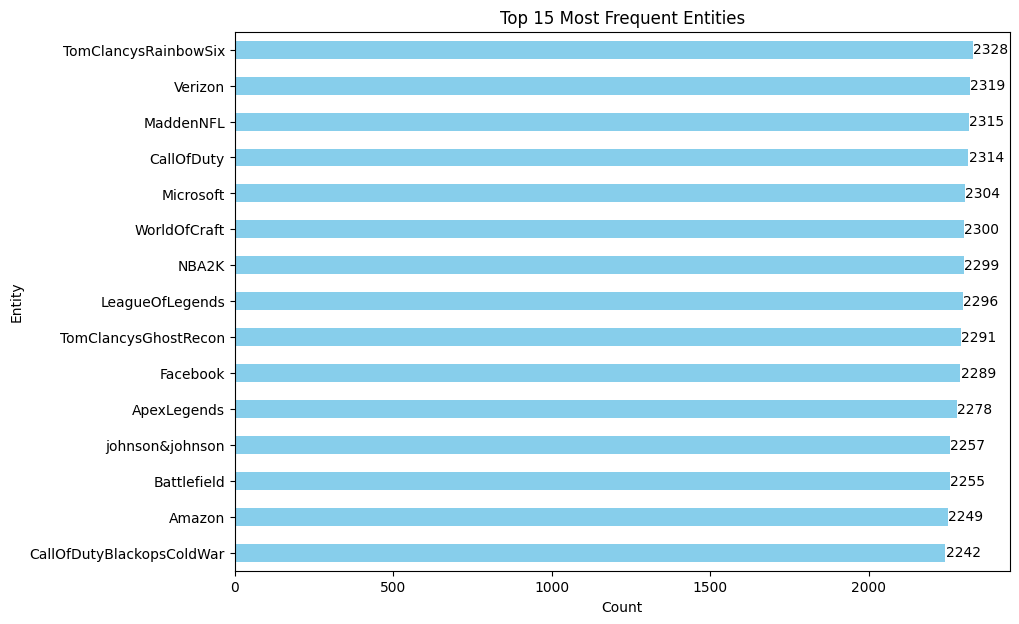

In [26]:
top_entities = df['Entity'].value_counts().head(15).sort_values()
top_entities.plot(kind='barh', color='skyblue', figsize=(10,7))

for i, v in enumerate(top_entities):
    plt.text(v + 0.8, i, str(v), ha='left', va='center')

# Add title and labels
plt.title('Top 15 Most Frequent Entities')
plt.xlabel('Count')
plt.ylabel('Entity')
plt.show()

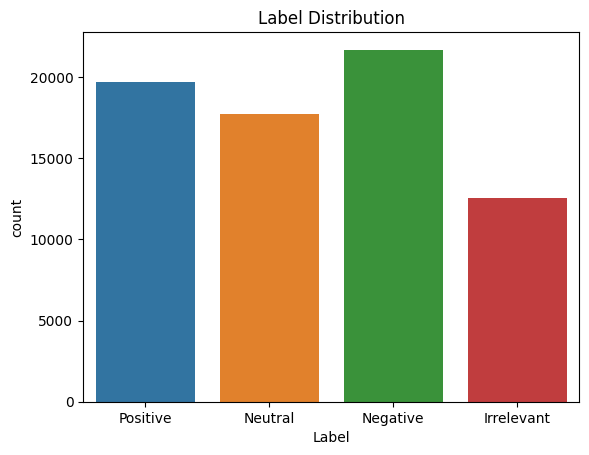

In [13]:
sns.countplot(df, x='Label')
plt.title('Label Distribution')
plt.show()

# Feature Engineering

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

In [28]:
import spacy
import re
# !python -m spacy download en_core_web_sm

# load english vocab and create nlp object from it
nlp = spacy.load("en_core_web_sm") 

In [29]:
def preprocess(text):
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)  # remove links
    text = re.sub(r"[^a-zA-Z\s]", "", text) # remove numbers and sympols
    text = re.sub(r'\s+', ' ', text) # remove extra spaces
    doc = nlp(text, disable=["ner", "parser", "senter"])  # tokenize text / Disable unnecessary components (NER, parser))

    # remove stop words and punctuation and lemmatize the text
    filtered_tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]

    return " ".join(filtered_tokens) 

In [31]:
# Initialize tqdm with pandas
tqdm.pandas()

df['Preprocessed_Message'] = df['Message'].progress_apply(preprocess) 

  0%|          | 0/71656 [00:00<?, ?it/s]

In [32]:
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

In [34]:
from collections import Counter

words = df['Preprocessed_Message'].str.split(expand=True).stack()
top = Counter(words).most_common(20)
temp = pd.DataFrame(top, columns=['Common_words','count'])

fig = px.bar(temp, x="count", y="Common_words", title='Commmon Words in Messages', orientation='h', 
             width=700, height=700,color='Common_words')
fig.show()

In [36]:
negative_words = df[df['Label']==2]['Preprocessed_Message'].str.split(expand=True).stack()
top = Counter(negative_words).most_common(20)
temp = pd.DataFrame(top, columns=['Common_words','count'])

fig = px.treemap(temp, path=['Common_words'], values='count',title='Tree Of Most Common Negative Words')
fig.show()

In [37]:
positive_words = df[df['Label']==3]['Preprocessed_Message'].str.split(expand=True).stack()
top = Counter(positive_words).most_common(20)
temp = pd.DataFrame(top, columns=['Common_words','count'])

fig = px.treemap(temp, path=['Common_words'], values='count',title='Tree Of Most Common Positive Words')
fig.show()

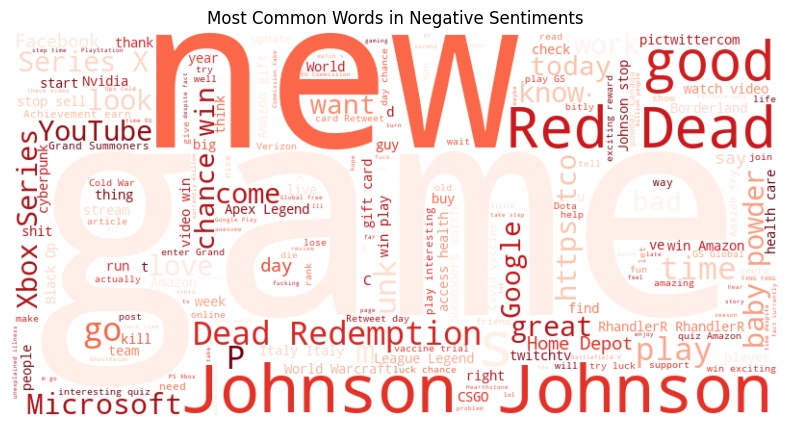

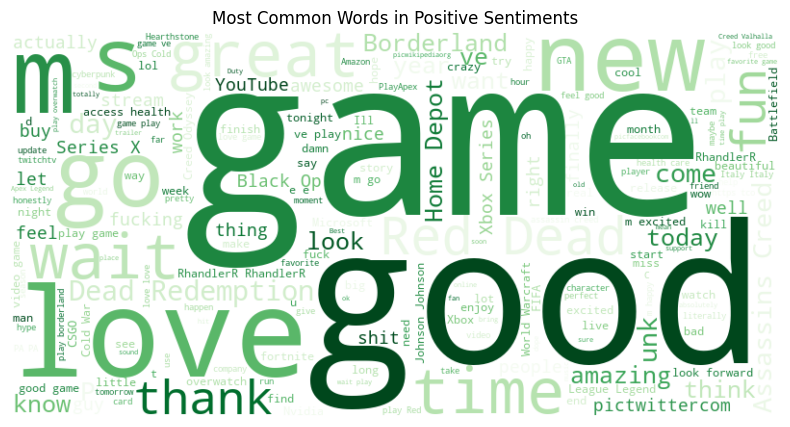

In [39]:
from wordcloud import WordCloud

# negative words
negative_text = " ".join(df[df['Label'] == 2]['Preprocessed_Message'])

negative_wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Sentiments')
plt.show()

# positive words
positive_text = " ".join(df[df['Label'] == 3]['Preprocessed_Message'])

positive_wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Sentiments')
plt.show()

# Training Model

In [40]:
X_train, X_test, y_train, y_test = train_test_split(df['Preprocessed_Message'],
                                                    df['Label'], 
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=df['Label'])


In [41]:
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)

Shape of X_train:  (57324,)
Shape of X_test:  (14332,)


In [32]:
## Naive Bayes Model
clf = Pipeline([
    ('vectorizer_tri_grams', TfidfVectorizer(ngram_range=(3, 3))),
    ('naive_bayes', (MultinomialNB()))         
])

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score:  0.8343566843427296
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.75      0.85      2507
           1       0.66      0.99      0.79      4340
           2       0.98      0.83      0.90      3542
           3       0.97      0.73      0.83      3943

    accuracy                           0.83     14332
   macro avg       0.90      0.82      0.84     14332
weighted avg       0.88      0.83      0.84     14332



In [33]:
# Random Forest Classifier
clf = Pipeline([
    ('vectorizer_tri_grams', TfidfVectorizer(ngram_range=(3, 3))),
    ('random_forest', (RandomForestClassifier()))         
])

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score:  0.7869801842031817
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.67      0.80      2507
           1       0.96      0.74      0.84      4340
           2       0.95      0.72      0.82      3542
           3       0.58      0.97      0.73      3943

    accuracy                           0.79     14332
   macro avg       0.87      0.78      0.80     14332
weighted avg       0.86      0.79      0.80     14332

